[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Intertangler/CB2330-exercises/blob/main/04_generative_models/exercise.ipynb)

# Session 04 - Generative Models and Monte Carlo

In this exercise we will build the generator of the video and put it to work: a linear congruential generator that turns an integer state into a draw on $[0, 1)$, the partition rule that turns a draw into an outcome, a PCR tube copied molecule by molecule, and the residence time of an oligonucleotide sampled twice, once by walking the process and once by inverting $F$. The draws come from our own generator throughout, so a seed fixes the notebook's output.

I've written the constants, the check cells and the figures already.

**Deliverable:** this notebook, run, committed to `cb2330-portfolio`, with its figures rendered on the published page and a sentence under the figures saying what they show.

---

# Part A

## 0. The `while` loop

A `for` loop runs a number of times fixed before it starts. A `while` loop runs until its condition stops being true, so the number of passes is not known in advance. The cell below doubles a count until it passes 100.

In [83]:
n_doublings = 0
copies = 1
while copies < 100:
    copies = copies * 2
    n_doublings = n_doublings + 1
print("doublings needed to pass 100:", n_doublings, "  copies:", copies)


doublings needed to pass 100: 7   copies: 128


## 1. The generator

This section is aimed at the generator: a recurrence on integers whose output is indistinguishable from randomness for our purposes, and which gives the same stream from the same seed. We will write the recurrence, reproduce the table the page drew by hand at $a = 5$, $c = 3$, $m = 16$ from seed 6, and then run it with constants used in practice to get 10000 draws.

$$s_{i+1} = (a\,s_i + c) \bmod m, \qquad r_i = \frac{s_i}{m}$$

`lcg` takes a state and the constants and returns the next state. `%` is the modulo operator, the remainder after division: `9 % 2` is 1.

`uniforms` runs the generator $k$ times from a seed with the constants above it, dividing the states by $m$. The check cell tests that the draws stay in $[0, 1)$, that their mean is near 0.5, that the draws spread evenly over the tenths of the interval, and that a seed fixes the stream.

**Fill the gaps to write the generator.** `lcg` receives `state`, `a`, `c` and `m` and returns the next state from the formula above, with `%` for mod. `uniforms` receives `k` and `seed`, sets `out` up as `k` zeros and `state` as the seed, and returns `out`. Write the loop over `range(k)` that advances `state` with `lcg(state, A, C, M)` and stores `state / M` in `out[i]`.

In [84]:
def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    return (a * state + c) % m


In [85]:
# The generator of the video's page, run by hand: a = 5, c = 3, m = 16, seed 6.
state = 6
states = [0] * 6
rs = [0.0] * 6
print("step   state   r = state / m")
for i in range(6):
    states[i] = state
    rs[i] = state / 16
    print(f"{i + 1:4d}   {state:5d}   {state / 16:.4f}")
    state = lcg(state, 5, 3, 16)

assert states == [6, 1, 8, 11, 10, 5], states
assert rs == [0.375, 0.0625, 0.5, 0.6875, 0.625, 0.3125], rs
print("ok, the page's table")


step   state   r = state / m
   1       6   0.3750
   2       1   0.0625
   3       8   0.5000
   4      11   0.6875
   5      10   0.6250
   6       5   0.3125
ok, the page's table


In [86]:
# The constants used from here on. m = 2^32, so a state is an integer below 4 294 967 296.
A = 1664525
C = 1013904223
M = 2 ** 32


def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    for i in range(k):
      state = lcg(state, A, C, M)
      out[i] = state / M
    return out


In [87]:
rs = uniforms(10000, 2026)

total = 0.0
for r in rs:
    total = total + r
mean_r = total / len(rs)

# how many draws fall in each tenth of the interval
tenths = [0] * 10
for r in rs:
    for b in range(10):
        if r >= b / 10 and r < (b + 1) / 10:
            tenths[b] = tenths[b] + 1

assert min(rs) >= 0.0 and max(rs) < 1.0, (min(rs), max(rs))
assert abs(mean_r - 0.5) < 0.01, mean_r
assert min(tenths) > 900 and max(tenths) < 1100, tenths
assert uniforms(5, 2026) == rs[:5], "the same seed gives the same stream"
assert uniforms(5, 7) != rs[:5], "a different seed gives a different stream"

print("ok   mean of 10000 draws:", round(mean_r, 4))
print("     draws per tenth of [0, 1):", tenths)
print("     first draws from seed 2026:", round(rs[0], 4), round(rs[1], 4), round(rs[2], 4))


ok   mean of 10000 draws: 0.4991
     draws per tenth of [0, 1): [1044, 992, 1000, 1003, 942, 1009, 993, 1021, 970, 1026]
     first draws from seed 2026: 0.0212 0.0444 0.0385


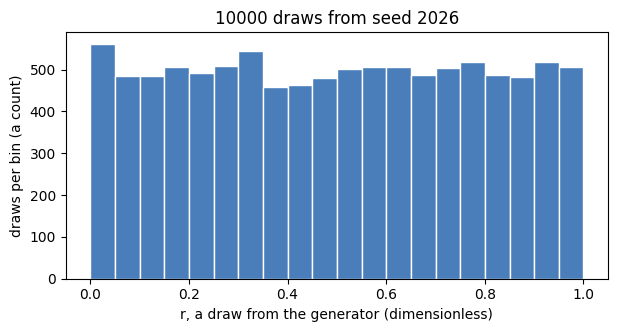

In [88]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(rs, bins=20, color="#4a7ebb", edgecolor="white")
ax.set_xlabel("r, a draw from the generator (dimensionless)")
ax.set_ylabel("draws per bin (a count)")
ax.set_title("10000 draws from seed 2026")
plt.show()


## 2. The partition rule

Here we turn a draw into an outcome. The partition rule carves $[0, 1)$ into slices whose widths are the probabilities, and the draw picks the slice it lands in, so the fair die, the loaded die and a biased coin are the same function called with a different list.

The page wrote the rule as

$$\text{report } x_k \text{ when } \sum_{j<k} p_j \;\le\; r \;<\; \sum_{j \le k} p_j$$

`choose` takes a draw and a list of probabilities and returns the position $k$ of the outcome, counted from 0, so a die face is $k + 1$.

The check cell runs the page's $r$ values through the fair die and compares the faces with the page's, then runs the loaded die with $P\{x = 1\} = 0.5$. The cell after it rolls the fair die 6000 times and compares the face frequencies with $1/6$. The last cell is the coin of the page, heads with probability 0.3.

**Fill the gap to write the partition rule.** `choose` receives `r` and `probs` and returns `k`. Start `running` at zero, then loop over `range(len(probs))`, adding `probs[k]` to `running` and returning `k` as soon as `r < running`. The line after the loop is given, and it catches a draw above the rounded edge of the last slice.

In [89]:
def choose(r, probs):
    """The partition rule: the outcome k whose slice of [0, 1) contains r.

    probs[k] is the probability of outcome k, and the slices are laid end to end
    in order, so outcome k owns the interval from probs[0] + ... + probs[k-1] up to
    probs[0] + ... + probs[k].  Returns k as a position in probs, from 0."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    cumulative_running_total = 0
    for k in range(len(probs)):
      cumulative_running_total = cumulative_running_total + probs[k]
      if r < cumulative_running_total:
        return k
    return len(probs) - 1     # rounding can leave the slices summing to 0.9999999999999999


In [90]:
# 6000 rolls of the fair die, and the frequency of each face against 1/6
rolls = [0] * 6000
rs = uniforms(6000, 1)
for i in range(6000):
    rolls[i] = choose(rs[i], FAIR) + 1

print("face   rolls   frequency")
for face in range(1, 7):
    n_face = 0
    for roll in rolls:
        if roll == face:
            n_face = n_face + 1
    print(f"{face:4d}   {n_face:5d}   {n_face / len(rolls):.4f}")
    assert abs(n_face / len(rolls) - 1 / 6) < 0.02, (face, n_face)
print("ok   every frequency within 0.02 of 1/6")


face   rolls   frequency
   1    1011   0.1685
   2    1011   0.1685
   3     988   0.1647
   4    1003   0.1672
   5    1036   0.1727
   6     951   0.1585
ok   every frequency within 0.02 of 1/6


In [91]:
# A coin that comes up heads 30 % of the time: two slices, heads first.
COIN = [0.3, 0.7]

n_heads = 0
for r in uniforms(10000, 3):
    if choose(r, COIN) == 0:
        n_heads = n_heads + 1
assert abs(n_heads / 10000 - 0.3) < 0.02, n_heads
print("ok   heads in 10000 flips:", n_heads, "  frequency", n_heads / 10000)


ok   heads in 10000 flips: 3001   frequency 0.3001


## 3. Mimicking a process: PCR

The PCR tube is the process of the video's closing question: a rule for what happens to a molecule in a cycle, and no formula for what a tube holds after 15 of them. We will run the rule 300 times and let the histogram of the results be the distribution. Doubling per cycle, which is how PCR is usually drawn, is the case $p = 1$. A real reaction copies a molecule with a probability below 1.

A tube starts with 1 template molecule. In a cycle, a molecule present is copied with probability $p$ and left uncopied otherwise, so a cycle multiplies the expected number of molecules by $1 + p$:

$$E(\text{molecules after } C \text{ cycles}) = (1 + p)^C$$

The cell below runs 300 tubes for 15 cycles at $p = 0.8$ and records the final count per tube. The check cell compares the mean of the tubes with $(1 + p)^C$ and plots the histogram of the counts.

**Fill the gap to run a cycle.** The loops over tubes, cycles and molecules are given, and so is the draw `r` for a molecule. Inside the molecule loop, add 1 to `copies` when `r < P`. After the molecule loop, at the indent of the cycle loop, add `copies` to `molecules`.

In [92]:
# PCR from a single template molecule. In each cycle every molecule present is copied
# with probability P and left uncopied otherwise.
P = 0.8              # the chance a molecule is copied in one cycle
CYCLES = 15
REPLICATES = 300     # tubes, each run from one molecule
SEED = 2026


In [106]:
state = SEED
finals = [0] * REPLICATES

for tube in range(REPLICATES):
    molecules = 1
    for cycle in range(CYCLES):
        copies = 0
        for molecule in range(molecules):
            state = lcg(state, A, C, M)
            r = state / M

            # ⭐⭐⭐ Your code here ⭐⭐⭐
            if r <P:
              copies = copies + 1
        molecules = molecules + copies
        pass
        finals[tube] = molecules

print("tubes:", len(finals), "  smallest:", min(finals), "  largest:", max(finals))


tubes: 300   smallest: 697   largest: 11423


ok   mean copies per tube: 6781.4   (1 + p)^15 = 6746.6   doubling would give 2^15 = 32768


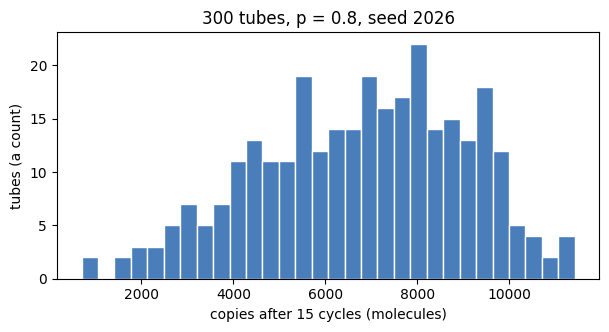

In [107]:
total = 0.0
for value in finals:
    total = total + value
mean_final = total / len(finals)
mean_theory = (1 + P) ** CYCLES

assert min(finals) >= 1
assert abs(mean_final - mean_theory) / mean_theory < 0.1, (mean_final, mean_theory)
print("ok   mean copies per tube:", round(mean_final, 1), "  (1 + p)^15 =", round(mean_theory, 1),
      "  doubling would give 2^15 =", 2 ** CYCLES)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(finals, bins=30, color="#4a7ebb", edgecolor="white")
ax.set_xlabel("copies after 15 cycles (molecules)")
ax.set_ylabel("tubes (a count)")
ax.set_title("300 tubes, p = 0.8, seed 2026")
plt.show()


## 4. Sampling a waiting time

The residence time of a bound oligonucleotide is the object of this section, the continuous example of the distributions video, and we will sample it twice. Route A mimics the process and route B inverts the distribution function of the page, and the check is that route A and route B agree with $F(t)$.

The oligonucleotide falls off at a rate $\theta$ per second, and the distribution function of the wait is the page's:

$$F(t) = 1 - e^{-\theta t}$$

| route | the sample | what a sample costs |
|---|---|---|
| A, the process | chop time into slices of $\Delta t$; in a slice the molecule falls off with probability $\theta\,\Delta t$; the wait is the slices until it does, times $\Delta t$ | a draw per slice |
| B, the inverse transform | set $F(t) = r$ and solve: $t = -\ln(1 - r)/\theta$ | a draw per sample |

Route A is a `while` loop, because the number of slices is not known in advance. Route B is `wait_from_uniform`, and `math.log` is the natural logarithm.

The check cells compare the means of the routes with $1/\theta$, and compare $\widehat{F}(t)$ of the routes, the fraction of the waits at or below $t$, with $F(t)$ on a grid of $t$. The plot draws $\widehat{F}$ of the routes and $F$.

**Fill the gaps to sample the wait by the routes.** In route A, `slices` starts at 0 and `fallen` at `False`. Write a `while fallen == False` loop that advances `state` with `lcg(state, A, C, M)`, sets `r` to `state / M`, adds 1 to `slices`, and sets `fallen` to `True` when `r < THETA * DT`. In route B, `wait_from_uniform` receives `r` and `theta` and returns $t$ from the formula in the table, with `math.log` for $\ln$.

In [108]:
# The residence time of a bound oligonucleotide, in seconds. The rate theta is the chance
# per second that it falls off, and the distribution function on the page is
# F(t) = 1 - exp(-theta t).
THETA = 1.0          # per second
N_SAMPLES = 2000


In [109]:
# Route A: mimic the process. Chop time into slices of DT seconds; in each slice the
# molecule falls off with probability THETA * DT, and the wait is the number of slices
# until it does, times DT.
DT = 0.01            # seconds per slice

state = 7
waits_sim = [0.0] * N_SAMPLES
for i in range(N_SAMPLES):
    slices = 0
    fallen = False
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    while fallen == False:
      lcg(state, A, C, M)
      r = state/M
      slices = slices + 1

      if r< theta *dt:
        fallen = True



    waits_sim[i] = slices * DT

total = 0.0
for t in waits_sim:
    total = total + t
mean_sim = total / len(waits_sim)
assert abs(mean_sim - 1 / THETA) < 0.1, mean_sim
print("ok   route A, mean wait:", round(mean_sim, 3), "s   draws used:", round(total / DT))


NameError: name 'theta' is not defined

In [ ]:
import math      # math.log is the natural logarithm, the ln on the page


def wait_from_uniform(r, theta):
    """Set F(t) = 1 - exp(-theta t) equal to r and solve for t."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    pass


assert abs(wait_from_uniform(0.831, 1.0) - 1.78) < 0.01, wait_from_uniform(0.831, 1.0)
assert wait_from_uniform(0.0, 1.0) == 0.0

waits_inv = [0.0] * N_SAMPLES
rs = uniforms(N_SAMPLES, 99)
for i in range(N_SAMPLES):
    waits_inv[i] = wait_from_uniform(rs[i], THETA)

total = 0.0
for t in waits_inv:
    total = total + t
mean_inv = total / len(waits_inv)
assert abs(mean_inv - 1 / THETA) < 0.1, mean_inv
print("ok   route B, mean wait:", round(mean_inv, 3), "s   draws used:", N_SAMPLES)
print("     r = 0.831 gives t =", round(wait_from_uniform(0.831, THETA), 2), "s, the page's number")


In [ ]:
def F_hat(times, t):
    """The empirical distribution function: the fraction of the times at or below t."""
    n_below = 0
    for value in times:
        if value <= t:
            n_below = n_below + 1
    return n_below / len(times)


def F_exp(t, theta):
    """The distribution function on the page, F(t) = 1 - exp(-theta t)."""
    return 1 - math.exp(-theta * t)


print("   t     route A   route B   1 - exp(-t)")
worst = 0.0
for i in range(61):
    t = i * 0.1
    gap_a = abs(F_hat(waits_sim, t) - F_exp(t, THETA))
    gap_b = abs(F_hat(waits_inv, t) - F_exp(t, THETA))
    if gap_a > worst:
        worst = gap_a
    if gap_b > worst:
        worst = gap_b
    if i in [5, 10, 20, 30, 50]:
        print(f"{t:4.1f}     {F_hat(waits_sim, t):.4f}    {F_hat(waits_inv, t):.4f}    {F_exp(t, THETA):.4f}")
assert worst < 0.04, worst
print("ok   largest gap between an F hat and F on the grid:", round(worst, 4))


In [ ]:
ts = [0.0] * 61
fa = [0.0] * 61
fb = [0.0] * 61
ft = [0.0] * 61
for i in range(61):
    ts[i] = i * 0.1
    fa[i] = F_hat(waits_sim, ts[i])
    fb[i] = F_hat(waits_inv, ts[i])
    ft[i] = F_exp(ts[i], THETA)

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ts, fa, color="#4a7ebb", label="route A, the sliced process")
ax.plot(ts, fb, color="#d1495b", label="route B, the inverse transform")
ax.plot(ts, ft, color="black", linestyle="--", label="F(t) = 1 - exp(-t)")
ax.set_xlabel("t, residence time (s)")
ax.set_ylabel("F(t), probability of having fallen off by t (dimensionless)")
ax.legend()
plt.show()


## 5. Summary statistics from the samples

The expected value returns here in the empirical form of the page, with the samples coming from our simulation rather than from an instrument. We will compute the mean and the variance of the tubes and of the residence times with the same $1/N$ weighting as before.

$$\widehat{E}\big(u(x)\big) = \sum_{i=1}^{N} u(x_i)\,\frac{1}{N}$$

| $u(x)$ | $\widehat{E}(u)$ | in the code |
|---|---|---|
| $x$ | the mean | `expected_mean` |
| $(x - \mu)^2$ | the variance, with $\mu$ the mean above | `expected_variance` |

The check cell tests the functions on lists whose answers are known, then runs them on the PCR tubes and on the residence times of route B, where the mean and the standard deviation are $1/\theta$.

**Fill the gap to write the variance.** `expected_mean` is written. In `expected_variance`, `mu` and `total` are set up. Write the loop over `values` that adds `(x - mu) ** 2 * (1 / len(values))` to `total`.

In [ ]:
def expected_mean(values):
    """E hat of u(x) = x: each value weighted by 1/N."""
    total = 0.0
    for x in values:
        total = total + x * (1 / len(values))
    return total


def expected_variance(values):
    """E hat of u(x) = (x - mu)^2, with mu the plug-in mean."""
    mu = expected_mean(values)
    total = 0.0
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    return total


In [ ]:
assert abs(expected_mean([1, 2, 3, 4]) - 2.5) < 1e-12
assert abs(expected_variance([2, 2, 2]) - 0.0) < 1e-12
assert abs(expected_variance([1, 3]) - 1.0) < 1e-12

mu_pcr = expected_mean(finals)
sigma_pcr = expected_variance(finals) ** 0.5
mu_wait = expected_mean(waits_inv)
sigma_wait = expected_variance(waits_inv) ** 0.5

assert abs(mu_pcr - mean_final) < 1e-6
assert abs(mu_wait - 1 / THETA) < 0.1 and abs(sigma_wait - 1 / THETA) < 0.1, (mu_wait, sigma_wait)
print("ok")
print("  copies per tube    mean", round(mu_pcr, 1), "  sigma", round(sigma_pcr, 1), "molecules")
print("  residence time     mean", round(mu_wait, 3), "  sigma", round(sigma_wait, 3), "s",
      "  (1 / theta =", 1 / THETA, "s for both)")


---

# Part B. The proximity detection experiment

In Part B the object is the proximity detection experiment of the video: A and B molecules placed uniformly on a square of side 1, and a B molecule fluoresces when an A molecule is within $r_{\text{crit}}$ of it. The experiment is the case where the mechanism is easy to write and the formula isn't. We will place the molecules, measure the distances and count the activations, and compare with the formula where the formula holds.

Part B is optional and done outside the session.

The analytical route the page marks as difficult gives the fraction activated as

$$1 - e^{-\lambda \pi r_{\text{crit}}^2}$$

with $\lambda$ the density of A molecules per unit area. The Monte Carlo route places the points with `uniforms`, measures the distances,

$$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

and counts the B molecules with an A molecule closer than $r_{\text{crit}}$.

The check cell compares the routes over a range of $r_{\text{crit}}$ and plots them. The simulated fraction sits below the formula at the larger radii, because a B molecule near the edge of the square has fewer neighbours than the formula assumes, and the formula assumes an infinite plane.

**Fill the gaps to run the experiment.** `distance` receives the coordinates of a pair of points and returns the formula above. In `fraction_activated`, the loop over the B molecules is given with `active` set up as zero. Inside it, set `hit` to `False`, loop over the A molecules and set `hit` to `True` when the distance to B molecule `j` is below `r_crit`, then add 1 to `active` when `hit == True`.

In [ ]:
# The proximity detection experiment of the video: A and B molecules on a square of side 1,
# and a B molecule fluoresces when an A molecule is within r_crit of it.
N_A = 300            # A molecules, so the density lambda is 300 per unit area
N_B = 1000           # B molecules
xa = uniforms(N_A, 11)
ya = uniforms(N_A, 12)
xb = uniforms(N_B, 13)
yb = uniforms(N_B, 14)


def distance(x1, y1, x2, y2):
    """The Euclidean distance between two points."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    pass


def fraction_activated(xa, ya, xb, yb, r_crit):
    """The fraction of the B molecules with at least one A molecule closer than r_crit."""
    active = 0
    for j in range(len(xb)):
        # ⭐⭐⭐ Your code here ⭐⭐⭐
        pass
    return active / len(xb)


def fraction_formula(r_crit, lam):
    """The analytical route on the page: 1 - exp(-lambda pi r^2)."""
    return 1 - math.exp(-lam * math.pi * r_crit ** 2)


In [ ]:
assert distance(0, 0, 3, 4) == 5.0
assert fraction_activated(xa, ya, xb, yb, 0.0) == 0.0
assert fraction_activated(xa, ya, xb, yb, 2.0) == 1.0

r_crits = [0.01, 0.02, 0.03, 0.05, 0.08]
sim = [0.0] * 5
formula = [0.0] * 5
print("r_crit   simulated   formula")
for i in range(5):
    sim[i] = fraction_activated(xa, ya, xb, yb, r_crits[i])
    formula[i] = fraction_formula(r_crits[i], N_A)
    print(f"{r_crits[i]:6.2f}   {sim[i]:9.3f}   {formula[i]:7.3f}")
    assert abs(sim[i] - formula[i]) < 0.08, (r_crits[i], sim[i], formula[i])
print("ok")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(r_crits, sim, marker="o", color="#4a7ebb", label="simulated, 1000 B molecules")
ax.plot(r_crits, formula, linestyle="--", color="black", label="1 - exp(-lambda pi r^2)")
ax.set_xlabel("r_crit, the critical distance (side lengths of the square)")
ax.set_ylabel("fraction of B molecules activated (dimensionless)")
ax.legend()
plt.show()
